# Performance Evaluation

The first part of this notebook summarizes the conventional performance measures for an investment fund. The second part does a "style analysis" to find out how the fund has changed its portfolio weights over time.

## Load Packages and Extra Functions

In [1]:
using Printf, Dates, DelimitedFiles, Statistics

include("src/printmat.jl")
include("src/OlsM.jl");

In [2]:
using Plots

gr(size=(480,320))
default(fmt = :png)

# Loading Data

The weekly return data for the mutual funds that we will evaluate are in the matrix `R`, the benchmarks (a number of returns on different asset indices) in `Rb` and the riskfree rate in the vector `Rf`.

### A Remark on the Code
In the code below, `x` from `readdlm()` is an `Any` matrix (the first column are strings, the other columns are numbers). It often helps to convert to the right type. For the numbers in column `2:end` we can do that by `Float64.(x[:,2:end])` (or alternatively by `convert.(Float64,x[:,2:end])`).

In [3]:
(x,header) = readdlm("Data/Fin1StyleAnalysis.csv",',',header=true)
(IndNames,FundNames) = (header[2:9],header[11:12])     #names of variables

dN        = Date.(x[:,1],"yyyy-mm-dd")
(Rb,Rf,R) = (Float64.(x[:,2:9]),Float64.(x[:,10]),Float64.(x[:,11:12]))  #benchmarks, riskfree, funds

printblue("The data is weekly. The first 4 observations are:")
printmat(first(dN,4))

printmat(IndNames)
printmat(FundNames)

The data is weekly. The first 4 observations are:
1999-01-15
1999-01-22
1999-01-29
1999-02-05

   S&P 500
S&P Mid Cap
S&P US 600
DJ GlobalDevxUS
DJ GlobalEmerg
 Corporate
 US Tbills
U.S. Treasury

Putnam Asset Allocation: Growth A
Vanguard Wellington



# Performance Evaluation

The next few cells report a number of different performance measures for the funds. We annualize the weekly return statistics by multiplying by $\sqrt{52}$ or $52$, depending on the measure. In many cases, we also convert the numbers to percentage (%) by multiplying by $100$.

### A Remark on the Code

We use `Re` to denote excess returns for the funds and `Reₘ` the excess return of the market. (`Rᵉₘ` looks ugly, so we avoid it.) Similarly for `μe` and `μeₘ`.

In [4]:
Re  = R .- Rf           #excess returns of the funds
Reₘ = Rb[:,1] - Rf;     #excess returns of the marketₘ (S&P 500)

# Average Returns, Sharpe Ratio and M²

The Sharpe ratio (SR) is $\mu^e/\sigma$, where $\mu^e$ is the average excess return and $\sigma$ the standard deviation of the excess return. The $M^2$ is the difference of the SRs of a fund and the market, scaled by the standard deviation of the market.

Mean returns are annualized by $\times 52$ and standard deviations by $\times \sqrt{52}$, so a SR by $\times \sqrt{52}$.

In [5]:
"""
    SRFn(Re,Reₘ,AnnFactor=[])

Calculate Sharpe rations and M²
"""
function SRFn(Re,Reₘ,AnnFactor=Int[])
    μᵉ  = mean(Re,dims=1)
    μeₘ = mean(Reₘ)
    σ   = std(Re,dims=1)         #std, 1xn
    σₘ  = std(Reₘ)
    SR  = μᵉ./σ
    SRₘ = μeₘ/σₘ
    MM  = (SR .- SRₘ)*σₘ
    MMₘ = 0                             #(SRₘ.-SRₘ)*σₘ=0
    if !isempty(AnnFactor)
        (μᵉ,μeₘ,MM) = (μᵉ,μeₘ,MM).*AnnFactor
        (SR,SRₘ)    = (SR,SRₘ).*sqrt(AnnFactor)
    end
    return μᵉ, μeₘ, SR, SRₘ, MM
end

SRFn

In [6]:
(μᵉ, μeₘ, SR, SRₘ, MM) = SRFn(Re,Reₘ,52)

xut = hcat([μeₘ;μᵉ']*100,[SRₘ;SR'],[0;MM']*100)   #returns and MM in percent
printmat(xut;colNames=["ERe","SR","M²"],rowNames=["Market";FundNames])

                                        ERe        SR        M²
Market                                7.186     0.403     0.000
Putnam Asset Allocation: Growth A     5.456     0.369    -0.611
Vanguard Wellington                   5.978     0.530     2.260



# Appraisal Ratio, Traynor's Ratio and α

## Appraisal Ratio

Estimate a single index model

$R^e_t = \alpha + \beta R^e_{mt} + \epsilon_t$ 

The appraisal ratio (AR) is $\alpha/\mathrm{Std}(\epsilon)$.

## Treynor's Ratio and T²

Treynor's ratio is $\mu^e/\beta$, where $\beta$ is the slope from the single index regression.

### A Remark on The Code
- The `OlsM(y,x)` function (included above) does a regression for each of the $n$ columns in `y` on the same set of $K$ regressors in `x`. It returns ($K\times n$) coefficients `b` and ($1\times n$) standard deviations of the residuals `σ`.

In [7]:
"""
    AppraisalRatioFn(Re,Reₘ,AnnFactor=52)

Calculate appraisal ratio, Treynor's ratio and α.
"""
function ARTRFn(Re,Reₘ,AnnFactor=Int[])
    μᵉ  = mean(Re,dims=1)
    μeₘ = mean(Reₘ)
    T  = size(Re,1)
    (b,σₑ) = OlsM(Re,[ones(T) Reₘ])   #OLS regression for each column in Reₚ
    (α,β)  = (b[1:1,:],b[2:2,:])      #intercept and slopes (1xn)
    AR     = α./σₑ                    #α and σₑ are 1xn
    (Re == Reₘ) && (AR=0)             #impose this because α,σₑ close to 0 may give stange ratio
    TR     = μᵉ./β
    TT      = TR .- μeₘ
    if !isempty(AnnFactor)
        (α,TR,TT) = (α,TR,TT).*AnnFactor
        AR        = AR.*sqrt(AnnFactor)
    end
    return AR, TR, TT, α
end

ARTRFn

In [8]:
(AR,TR,TT,α)     = ARTRFn(Re,Reₘ,52)
(ARₘ,TRₘ,TTₘ,αₘ) = ARTRFn(Reₘ,Reₘ,52)

xut = hcat([ARₘ;AR'],[TRₘ;TR']*100,[TTₘ;TT']*100,[αₘ;α']*100)   #TR, TT and α in percent
printmat(xut,colNames=["AR","TR","T²","α"],rowNames=["Market";FundNames])

                                         AR        TR        T²         α
Market                                0.000     7.186     0.000    -0.000
Putnam Asset Allocation: Growth A    -0.071     6.831    -0.355    -0.284
Vanguard Wellington                   0.455     9.999     2.813     1.682



# Style Analysis

The regression is $Y = \sum_{j=1}^{K}b_j X_j + \varepsilon$,
               where $0 <= b_j$ and $\sum_{j=1}^{K}b_j = 1$. 
               
Write the sum of squared residuals of the regression as

$(Y-Xb)'(Y-Xb) = Y'Y - 2Y'Xb + b'X'Xb$.

Only the two last terms matter for the choice of $b$.

### A Remark on the Code
- The code uses the [OSQP.jl](https://github.com/osqp/OSQP.jl) package which solves problems of the type: $\min 0.5b'Pb + q'b$ subject to $l \leq Ab \leq u$. 
- The restricted regression (above) can easily be written in this form by letting $P=X'X/T$ and $q=-X'Y/T$. These choices give the loss function $0.5b'X'Xb/T - Y'Xb/T$, which is proportional ($0.5/T$) to the last two terms in the sum of squared residuals. Dividing by $T$ improves the numerical stability.
- The $A$ matrix is used to construct the restrictions ($b$ sums to 1 and $0 \leq b \leq 1$).

In [9]:
using LinearAlgebra, SparseArrays, OSQP   #OSQP needs SparseArrays

In [10]:
"""
    StyleAnalysisPs(Y,X)


# Input:
- `Y::Vector`:          T-vector, returns of a fund
- `X ::Matrix`:         TxK matrix, returns on m benchmarks

 # Output:
- `b_sa::Vector`:       K-vector, restricted regression coefficients
- `b_ls::Vector`:       K-vector, OLS regression coefficients
- `R2_sa::Number`:      pseudo-R2     

"""
function StyleAnalysisPs(Y,X)

    (T,K) = (size(X,1),size(X,2))
    b_ls = X\Y                          #LS estimate, no restrictions

    settings = Dict(:verbose => false)
    P = X'X/T
    q = -X'Y/T
    A = [ones(1,K);I]                  #1st restriction: sum(b)=1,
    l = [1;zeros(K)]                   #the rest: 0<=b<=1
    u = [1;ones(K)]

    settings = Dict(:verbose => false)
    model = OSQP.Model()    #(P,A) must be `Sparse`, (q,l,u) vectors of `Float64`
    OSQP.setup!(model; P=sparse(P), q=q, A=sparse(A), l=l, u=u, settings...)
    result = OSQP.solve!(model)
    b_sa = result.info.status == :Solved ? result.x : NaN

    Yhat = X*b_sa
    R2_sa  = cor(Y,Yhat)^2          #pseudo-R2

    return b_sa, b_ls, R2_sa

end

StyleAnalysisPs

The next cell makes a "style analysis regression" based on the entire sample. The dependent variable is the first mutual fund in R (see data loading) and the regressors include all indices (again, see data loading).

In [11]:
(b,b_ls,R2) = StyleAnalysisPs(R[:,2],Rb)

printblue("OLS and style analysis coeffs:")
colNames = ["OLS","Restricted LS"]
xut      = [b_ls b;sum([b_ls b],dims=1)]
printmat(xut;colNames,rowNames=[IndNames;"sum"],width=15)

printred("Notice that the restricted LS has (approximately) no negative coeffs and that sum(coeffs) = 1")

OLS and style analysis coeffs:
                           OLS  Restricted LS
S&P 500                  0.506          0.508
S&P Mid Cap              0.026          0.014
S&P US 600              -0.011         -0.000
DJ GlobalDevxUS          0.087          0.081
DJ GlobalEmerg          -0.006         -0.000
Corporate                0.280          0.276
US Tbills                0.753          0.117
U.S. Treasury           -0.007          0.004
sum                      1.628          1.000

Notice that the restricted LS has (approximately) no negative coeffs and that sum(coeffs) = 1


# Redo the Style Analysis on a Moving Data Window 

of size `WinSize` (see below). Then plot to see how the coefficients change over time. 

In [12]:
(T,K)   = size(Rb)
WinSize = 104

(b,R2) = (fill(NaN,T,K),fill(NaN,T))
for t in WinSize+1:T
    #local vv                 #local/global is needed in script
    vv     = (t-WinSize):t    #moving data window
    (b[t,:],_,R2[t]) = StyleAnalysisPs(R[vv,2],Rb[vv,:])
end

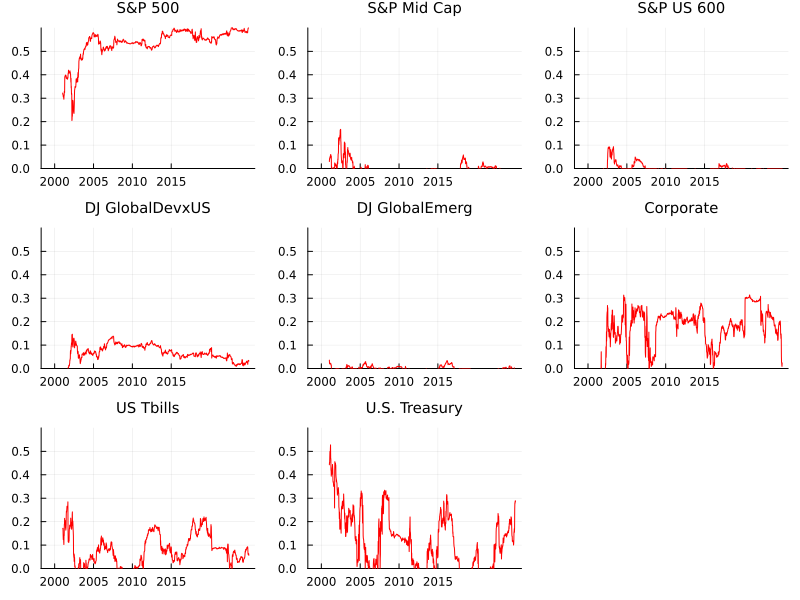

In [13]:
xTicksLoc = [Date(2000);Date(2005);Date(2010);Date(2015)]
xTicksLab = Dates.format.(xTicksLoc,"Y")

p1 = plot( dN,b,
           layout = @layout[a a a;a a a;a a _],   #_ to get blank subplot
           legend = false,
           size = (800,600),
           linecolor = :red,
           xticks = (xTicksLoc,xTicksLab),
           ylims = (0,0.6),
           title = reshape(string.(IndNames),1,:),
           titlefontsize = 10 )
display(p1)